In [1]:
import pandas as pd

df = pd.read_csv("03-jogja-mar-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,3/1/2021,00:00:00,13,48,19,15,35,6,48,PM2.5,Good
2,3/1/2021,01:00:00,14,51,19,16,36,6,51,PM2.5,Moderate
3,3/1/2021,02:00:00,15,52,20,17,37,6,52,PM2.5,Moderate
4,3/1/2021,03:00:00,16,54,20,17,37,6,54,PM2.5,Moderate
5,3/1/2021,04:00:00,17,55,21,18,38,6,55,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
740,3/31/2021,19:00:00,21,50,22,17,8,3,50,PM2.5,Good
741,3/31/2021,20:00:00,21,50,21,16,8,3,50,PM2.5,Good
742,3/31/2021,21:00:00,20,49,21,16,8,3,49,PM2.5,Good
743,3/31/2021,22:00:00,20,48,21,16,8,3,48,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 03-jogja-mar-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Date                744 non-null    str  
 1   Time                744 non-null    str  
 2   PM10                744 non-null    int64
 3   PM2.5               744 non-null    int64
 4   SO2                 744 non-null    int64
 5   CO                  744 non-null    int64
 6   O3                  744 non-null    int64
 7   NO2                 744 non-null    int64
 8   Max                 744 non-null    int64
 9   Critical Component  744 non-null    str  
 10  Category            744 non-null    str  
dtypes: int64(7), str(4)
memory usage: 64.1 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 03-jogja-mar-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,17.873656,44.424731,19.880376,12.037634,4.922043,3.793011,44.424731
std,6.276290,13.350931,2.623620,4.460828,7.092873,1.257079,13.350931
min,7.000000,19.000000,14.000000,4.000000,0.000000,2.000000,19.000000
25%,13.000000,35.000000,18.000000,8.000000,1.000000,3.000000,35.000000
50%,17.000000,42.000000,19.000000,11.000000,2.000000,3.000000,42.000000
75%,21.000000,53.000000,22.000000,15.000000,7.000000,4.000000,53.000000
max,41.000000,92.000000,27.000000,24.000000,38.000000,7.000000,92.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 03-jogja-mar-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 03-jogja-mar-2021.csv


Category
Good        67.607527
Moderate    32.392473
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the March data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - March 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In March 2021, PM2.5 stayed the highest all month with several ups and downs (roughly 20–85), while PM10 and CO stayed low and close together most of the time, and O3 dropped to near zero in the second half of the month.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 03-jogja-mar-2021.csv


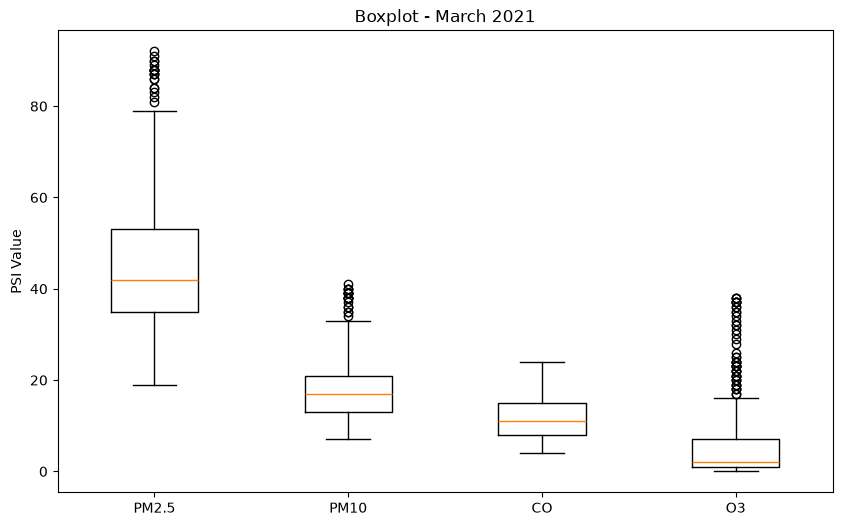

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - March 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In March 2021, PM2.5, PM10, and O3 all had high outliers (20, 20, and 51 points), with O3 having the highest, even though its median was low (2.0). CO had no outliers at all, and PM2.5 still had the highest median overall (42.0).**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 03-jogja-mar-2021.csv


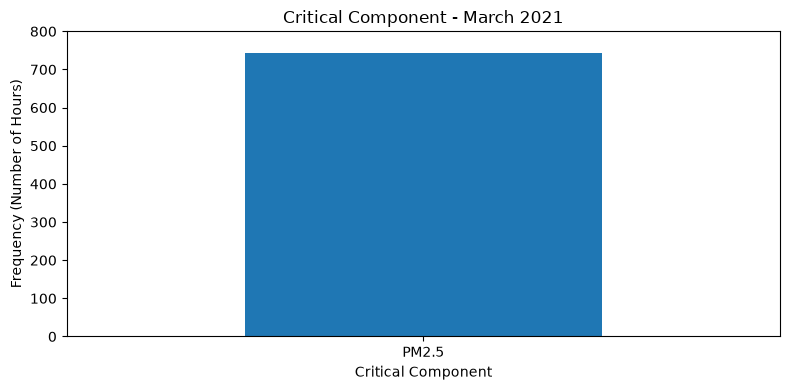

Critical Component
PM2.5    744
Name: count, dtype: int64

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")


plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - March 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  

**In March 2021, PM2.5 was the critical component for all 744 hours of the month, as no other pollutant (O3, CO, PM10, SO2) was ever the main driver of poor air quality.**

Data source: 03-jogja-mar-2021.csv


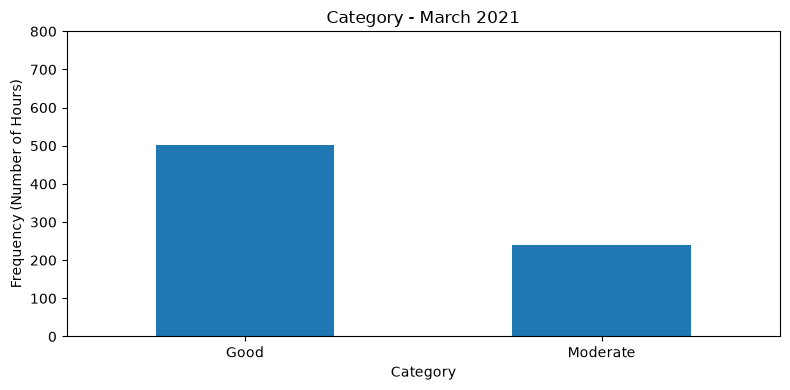

Category
Good        503
Moderate    241
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "03-jogja-mar-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - March 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

**In March 2021, most hours had Good air quality (503 hours), while 241 hours were moderate**